### For presidential party votes with a larger margin of victory are there more independent votes?

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/president_county_candidate.csv")
display(df)

,state,county,candidate,party,total_votes,won
0,Delaware,Kent County,Joe Biden,DEM,44552,True
1,Delaware,Kent County,Donald Trump,REP,41009,False
2,Delaware,Kent County,Jo Jorgensen,LIB,1044,False
3,Delaware,Kent County,Howie Hawkins,GRN,420,False
4,Delaware,New Castle County,Joe Biden,DEM,195034,True
...,...,...,...,...,...,...
32172,Arizona,Maricopa County,Write-ins,WRI,1331,False
32173,Arizona,Mohave County,Donald Trump,REP,78535,True
32174,Arizona,Mohave County,Joe Biden,DEM,24831,False
32175,Arizona,Mohave County,Jo Jorgensen,LIB,1302,False


In [4]:
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []


for group in df.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["total_votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
df_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "Winner": winner})

display(df_proportions)

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner
0,Alabama,0.365707,0.620310,0.013984,REP
1,Alaska,0.391993,0.485228,0.122779,REP
2,Arizona,0.493647,0.490560,0.015793,DEM
3,Arkansas,0.347751,0.623957,0.028292,REP
4,California,0.634992,0.343278,0.021730,DEM
5,Colorado,0.554000,0.418983,0.027017,DEM
6,Connecticut,0.592387,0.392095,0.015518,DEM
7,Delaware,0.587822,0.398014,0.014164,DEM
8,District of Columbia,0.921497,0.053973,0.024530,DEM
9,Florida,0.478615,0.512198,0.009187,REP


In [5]:
df_proportions["Dem-Rep"] = df_proportions["Proportion_Democrat"] - df_proportions["Proportion_Republican"]

display(df_proportions)

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner,Dem-Rep
0,Alabama,0.365707,0.620310,0.013984,REP,-0.254603
1,Alaska,0.391993,0.485228,0.122779,REP,-0.093235
2,Arizona,0.493647,0.490560,0.015793,DEM,0.003087
3,Arkansas,0.347751,0.623957,0.028292,REP,-0.276207
4,California,0.634992,0.343278,0.021730,DEM,0.291714
5,Colorado,0.554000,0.418983,0.027017,DEM,0.135017
6,Connecticut,0.592387,0.392095,0.015518,DEM,0.200292
7,Delaware,0.587822,0.398014,0.014164,DEM,0.189808
8,District of Columbia,0.921497,0.053973,0.024530,DEM,0.867524
9,Florida,0.478615,0.512198,0.009187,REP,-0.033584


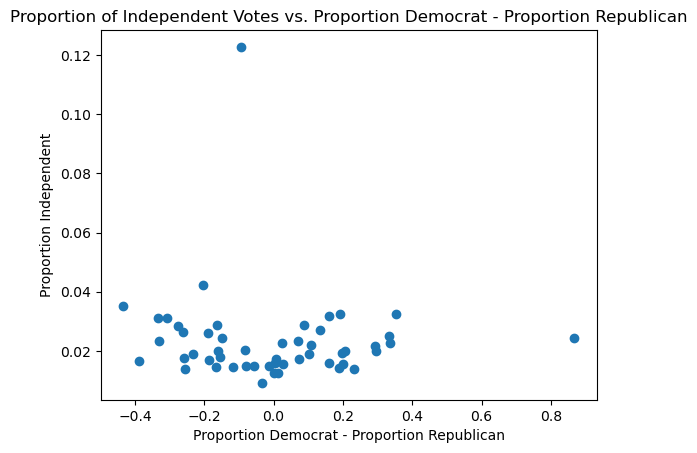

In [7]:
plt.scatter(df_proportions["Dem-Rep"], df_proportions["Proportion_Independent"])
plt.xlabel("Proportion Democrat - Proportion Republican")
plt.ylabel("Proportion Independent")
plt.title("Proportion of Independent Votes vs. Proportion Democrat - Proportion Republican")
plt.show()

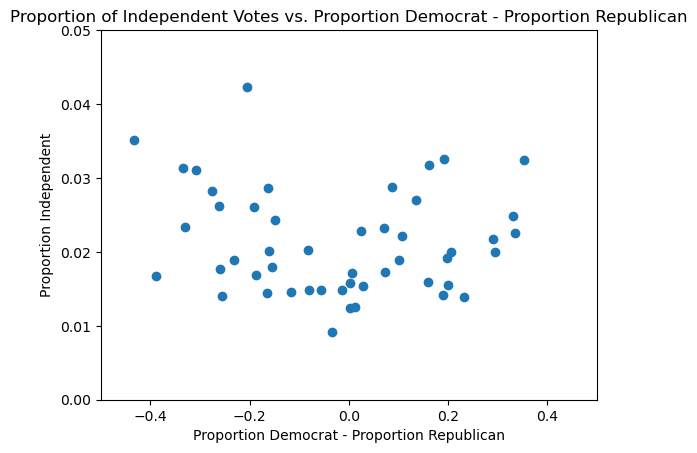

In [10]:
plt.scatter(df_proportions["Dem-Rep"], df_proportions["Proportion_Independent"])
plt.xlim(-0.5, 0.5) #removed outliers to better visualize the data
plt.ylim(0, 0.05)
plt.xlabel("Proportion Democrat - Proportion Republican")
plt.ylabel("Proportion Independent")
plt.title("Proportion of Independent Votes vs. Proportion Democrat - Proportion Republican")
plt.show()

In [11]:
df_proportions.to_csv("data/presidential_proportions.csv", index = False)